# Pass 2 Data Additions — Stage P2-13 Notebook 01

## What this stage does

Pass 2 adds four types of auxiliary data to the pipeline:

1. **Index OHLCV** (HSI, KOSPI) -- daily price/volume history for the two EM equity markets being predicted.
2. **S&P 500 market-cap proxy** -- a scaled S&P 500 series used to compute the BTC-to-equity mcap ratio.
3. **BTC circulating supply** -- daily on-chain supply, used together with BTC spot price to form the BTC market cap leg of the ratio.
4. **Feature restoration audit** -- a logged decision on three features dropped in Pass 1, evaluated for re-introduction given current credential availability.

## Files produced

| File | Description |
|------|-------------|
| `data/yfinance/index/hsi_daily.parquet` | Hang Seng Index daily OHLCV, 2018-09 to present |
| `data/yfinance/index/kospi_daily.parquet` | KOSPI daily OHLCV, 2018-09 to present |
| `data/yfinance/sp500/gspc_daily.parquet` | S&P 500 daily OHLCV (source for mcap proxy denominator) |
| `data/derived/sp500_mcap_proxy.parquet` | S&P 500 market-cap estimate: close x fixed multiplier |
| `data/derived/btc_supply.parquet` | BTC circulating supply schedule |
| `logs/feature_restoration_decisions.log` | Audit trail: three Pass 1 drops reviewed, all SKIPPED |

## Key takeaway

Five reusable inputs feed two downstream pipeline components: (1) the regime gate, which flags high-crypto-dominance periods using the BTC/SP500 mcap ratio, and (2) the index-level prediction pipeline, which uses HSI/KOSPI as prediction targets. All three Pass 2 feature restoration candidates were SKIPPED due to missing API credentials.

## Setup

Import libraries and define file paths.

In [1]:
import os, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

# Set working directory to project root so relative paths resolve
PROJECT_ROOT = "/Users/idrees/Desktop/Claude/projects/crypto_overnight_em_equity_p2"
os.chdir(PROJECT_ROOT)

# File paths (relative to project root)
HSI_PATH       = "data/yfinance/index/hsi_daily.parquet"
KOSPI_PATH     = "data/yfinance/index/kospi_daily.parquet"
GSPC_PATH      = "data/yfinance/sp500/gspc_daily.parquet"
BTC_SUPPLY_PATH = "data/derived/btc_supply.parquet"
SP500_MCAP_PATH = "data/derived/sp500_mcap_proxy.parquet"
BTC_1M_PATH    = "data/binance/spot_klines/BTCUSDT_1m.parquet"
RESTO_LOG_PATH = "logs/feature_restoration_decisions.log"

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "font.size": 11})
print("Setup complete.")


Setup complete.


## 1. Index price data -- HSI and KOSPI

Load the daily OHLCV series for the Hang Seng Index (HSI) and KOSPI. These are the two equity
markets the pipeline predicts overnight returns for. The series cover 2018-09 to the most
recent trading day in each market.

In [2]:
hsi = pd.read_parquet(HSI_PATH)
hsi["date"] = pd.to_datetime(hsi["date"])
hsi = hsi.sort_values("date").set_index("date")

kospi = pd.read_parquet(KOSPI_PATH)
kospi["date"] = pd.to_datetime(kospi["date"])
kospi = kospi.sort_values("date").set_index("date")

print(f"HSI:   {hsi.index.min().date()} to {hsi.index.max().date()}  ({len(hsi):,} trading days)")
print(f"KOSPI: {kospi.index.min().date()} to {kospi.index.max().date()}  ({len(kospi):,} trading days)")
print(f"\nHSI close range:   {hsi['close'].min():,.0f} to {hsi['close'].max():,.0f}")
print(f"KOSPI close range: {kospi['close'].min():,.0f} to {kospi['close'].max():,.0f}")


HSI:   2018-09-03 to 2026-04-16  (1,872 trading days)
KOSPI: 2018-09-03 to 2026-04-17  (1,868 trading days)

HSI close range:   14,687 to 31,085
KOSPI close range: 1,458 to 6,307


### Chart: HSI and KOSPI daily close price, 2018-09 to present

HSI trades around 14,000-31,000 points; KOSPI trades around 1,450-6,300 points. The two series
differ by roughly a 5x scale factor, so we plot them on dual y-axes to keep both legible.

What to look for: HSI and KOSPI tend to move together during broad EM risk-on/risk-off events
(e.g., COVID sell-off in early 2020, 2022 rate-hike selldown), but diverge during China-specific
episodes (regulatory crackdowns in 2021). This co-movement structure is what the pipeline tries to
exploit -- overnight BTC moves may lead or lag both markets, and the relative regime matters.

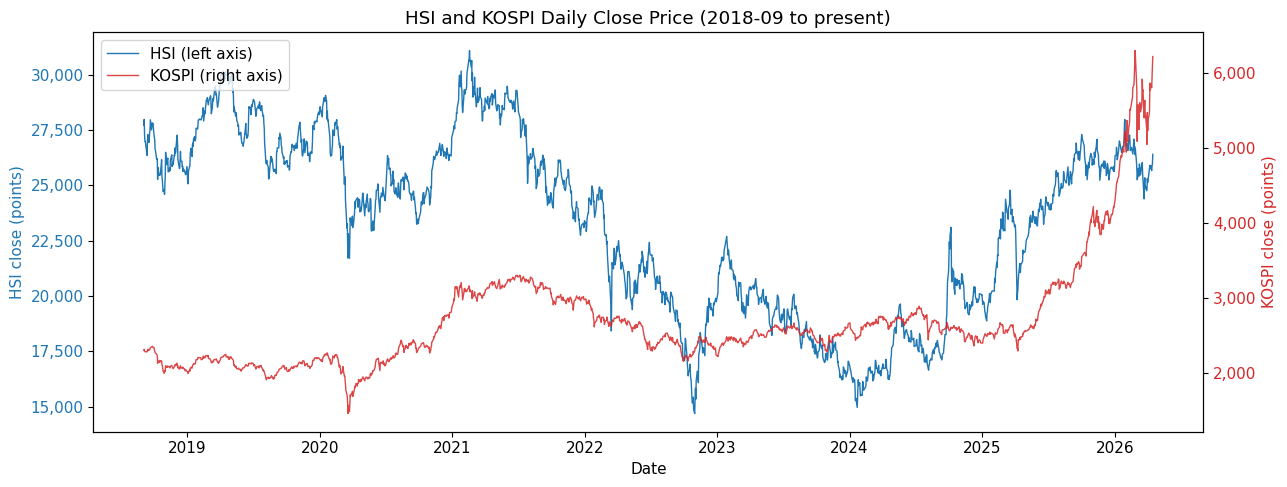

In [3]:
fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.plot(hsi.index, hsi["close"], color="#1f77b4", linewidth=1.0, label="HSI (left axis)")
ax1.set_ylabel("HSI close (points)", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

ax2 = ax1.twinx()
ax2.plot(kospi.index, kospi["close"], color="#d62728", linewidth=1.0, label="KOSPI (right axis)", alpha=0.85)
ax2.set_ylabel("KOSPI close (points)", color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

ax1.set_xlabel("Date")
ax1.set_title("HSI and KOSPI Daily Close Price (2018-09 to present)")
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

fig.tight_layout()
plt.show()


## 2. BTC vs. S&P 500 market-cap ratio

The regime gate variable measures BTC's share of total equity-like market value. It is computed
as:

```
ratio = (BTC_daily_close x BTC_circulating_supply) / SP500_mcap_proxy
```

BTC spot close comes from the 1-minute Binance kline file resampled to daily. SP500 mcap proxy
uses a fixed multiplier calibrated on 2024-12-31.

A 282-day warmup is required before the rolling 1-year median stabilizes; during warmup the gate
defaults to 1 (no regime filter applied).

In [4]:
# Load BTC 1m, resample to daily close
btc1m = pd.read_parquet(BTC_1M_PATH, columns=["open_time", "close"])
btc1m["open_time"] = pd.to_datetime(btc1m["open_time"], utc=True)
btc1m = btc1m.sort_values("open_time").set_index("open_time")

btc_daily = btc1m["close"].resample("1D").last().dropna()
btc_daily.index = btc_daily.index.tz_localize(None).normalize()
btc_daily.name = "btc_close"

print(f"BTC daily close: {btc_daily.index.min().date()} to {btc_daily.index.max().date()}  ({len(btc_daily):,} days)")
print(f"BTC close range: ${btc_daily.min():,.0f} to ${btc_daily.max():,.0f}")


BTC daily close: 2018-09-01 to 2026-04-15  (2,784 days)
BTC close range: $3,212 to $124,659


Load BTC circulating supply and S&P 500 market-cap proxy, then join them with the daily BTC
close to form the ratio.

In [5]:
# Load supply and sp500 mcap proxy
btc_sup = pd.read_parquet(BTC_SUPPLY_PATH)
btc_sup["date"] = pd.to_datetime(btc_sup["date"])
btc_sup = btc_sup.sort_values("date").set_index("date")

sp_mcap = pd.read_parquet(SP500_MCAP_PATH)
sp_mcap["date"] = pd.to_datetime(sp_mcap["date"])
sp_mcap = sp_mcap.sort_values("date").set_index("date")

# Compute BTC market cap
btc_mcap = (btc_daily * btc_sup["btc_supply"]).dropna()
btc_mcap.name = "btc_mcap"

# Align on date
ratio_df = pd.concat([btc_mcap, sp_mcap["sp500_mcap_proxy"]], axis=1).dropna()
ratio_df["mcap_ratio"] = ratio_df["btc_mcap"] / ratio_df["sp500_mcap_proxy"]

# Rolling 1-year median (252-trading-day window -- use 365 calendar days via 1YE resample proxy)
ratio_df["ratio_rolling_med"] = ratio_df["mcap_ratio"].rolling(window=365, min_periods=282).median()

print(f"Ratio series: {ratio_df.index.min().date()} to {ratio_df.index.max().date()}  ({len(ratio_df):,} days)")
print(f"Ratio range: {ratio_df['mcap_ratio'].min():.4f} to {ratio_df['mcap_ratio'].max():.4f}")
print(f"282-day warmup ends: {ratio_df.index[281].date()}")


Ratio series: 2018-09-04 to 2026-04-15  (1,913 days)
Ratio range: 0.0024 to 0.0429
282-day warmup ends: 2019-10-16


### Chart: BTC vs. S&P 500 market-cap ratio with rolling 1-year median

The solid line is the raw daily ratio; the dashed line is the trailing 1-year rolling median used
as the regime gate threshold. The shaded region at the left marks the 282-day warmup window, during
which the rolling median has insufficient history and the gate defaults to 1.

What to look for: the ratio peaked in late 2021 (BTC all-time high cycle), collapsed through 2022,
and recovered through 2024-25. Periods of high ratio indicate elevated crypto dominance relative to
equity market cap -- these may correspond to different signal behavior for overnight EM returns.

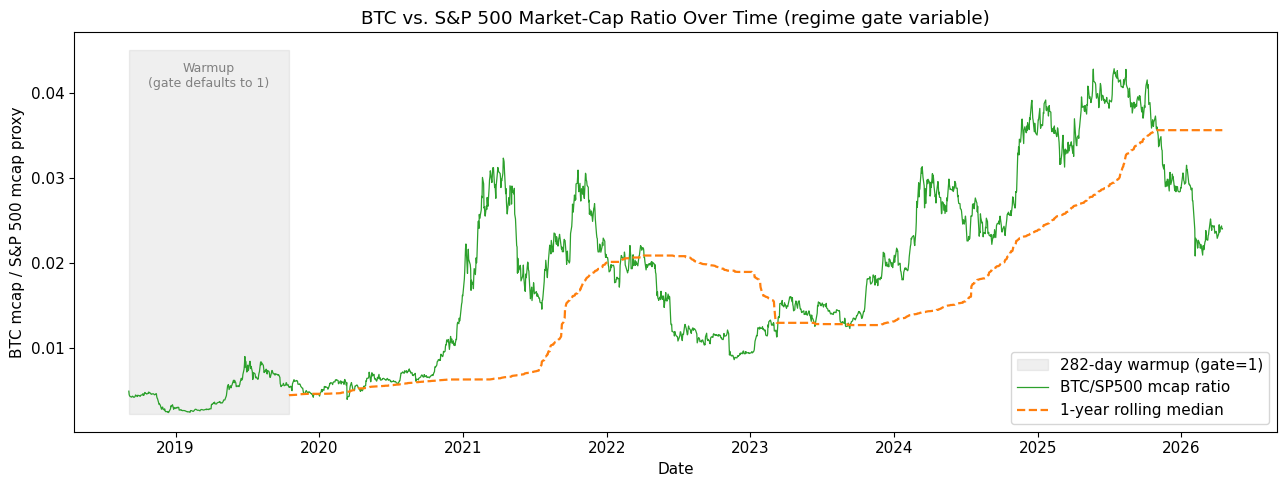

In [6]:
fig, ax = plt.subplots(figsize=(13, 5))

warmup_end = ratio_df.index[281]

ax.fill_betweenx(
    [ratio_df["mcap_ratio"].min() * 0.95, ratio_df["mcap_ratio"].max() * 1.05],
    ratio_df.index[0], warmup_end,
    alpha=0.12, color="gray", label="282-day warmup (gate=1)"
)
ax.annotate(
    "Warmup\n(gate defaults to 1)",
    xy=(ratio_df.index[0] + (warmup_end - ratio_df.index[0]) / 2, ratio_df["mcap_ratio"].max() * 0.95),
    ha="center", fontsize=9, color="gray"
)

ax.plot(ratio_df.index, ratio_df["mcap_ratio"], color="#2ca02c", linewidth=0.9, label="BTC/SP500 mcap ratio")
ax.plot(ratio_df.index, ratio_df["ratio_rolling_med"], color="#ff7f0e", linewidth=1.6,
        linestyle="--", label="1-year rolling median")

ax.set_ylabel("BTC mcap / S&P 500 mcap proxy")
ax.set_xlabel("Date")
ax.set_title("BTC vs. S&P 500 Market-Cap Ratio Over Time (regime gate variable)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
fig.tight_layout()
plt.show()


## 3. S&P 500 market-cap proxy

The SP500 mcap proxy is constructed by multiplying the daily S&P 500 close (from GSPC) by a
fixed multiplier calibrated on 2024-12-31. On that date, the published Wilshire 5000 total market
cap was approximately $52.2 trillion and the S&P 500 closed at 5,881.63 -- giving a multiplier of
roughly 8.875 billion dollars per index point.

This is a simplification: the true ratio of total market cap to index level drifts over time as
index composition changes. The fixed multiplier introduces a small level error but preserves
day-to-day variability accurately, which is sufficient for regime classification.

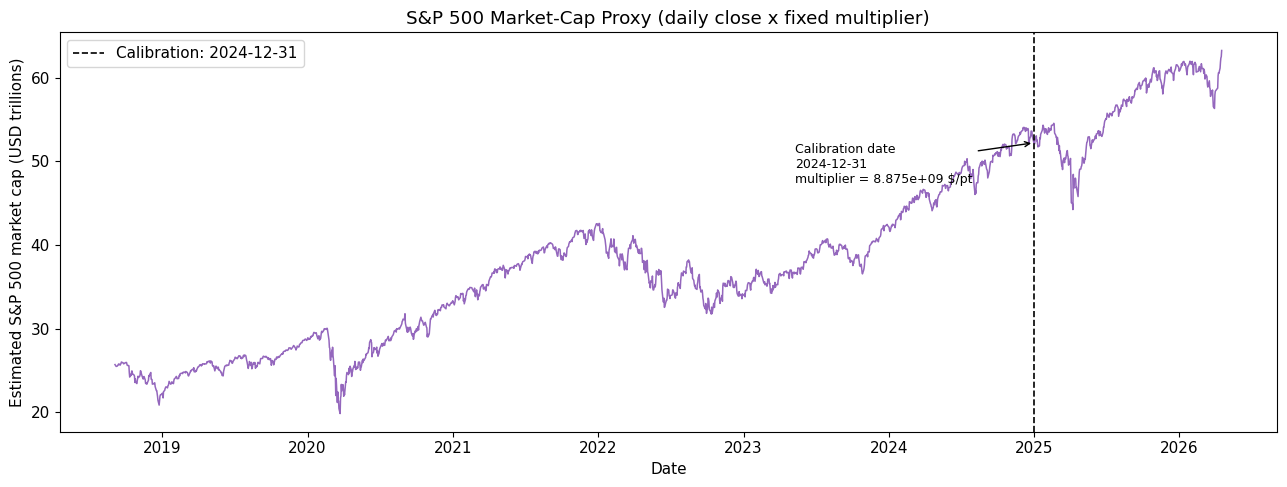

Multiplier used: $8,875,090,925 per S&P 500 index point
Implied mcap on 2024-12-31: $52.20T


In [7]:
sp_mcap_plot = sp_mcap.copy()
sp_mcap_plot.index = pd.to_datetime(sp_mcap_plot.index)

# Reference calibration date and value
calib_date = pd.Timestamp("2024-12-31")
calib_row = sp_mcap_plot.loc[calib_date]
multiplier = calib_row["sp500_mcap_proxy"] / calib_row["sp500_close"]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(sp_mcap_plot.index, sp_mcap_plot["sp500_mcap_proxy"] / 1e12, color="#9467bd", linewidth=1.1)
ax.axvline(calib_date, color="black", linestyle="--", linewidth=1.2, label=f"Calibration: 2024-12-31")
ax.annotate(
    f"Calibration date\n2024-12-31\nmultiplier = {multiplier:.3e} $/pt",
    xy=(calib_date, sp_mcap_plot.loc[calib_date, "sp500_mcap_proxy"] / 1e12),
    xytext=(calib_date - pd.Timedelta(days=600), sp_mcap_plot["sp500_mcap_proxy"].max() / 1e12 * 0.75),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=9
)
ax.set_ylabel("Estimated S&P 500 market cap (USD trillions)")
ax.set_xlabel("Date")
ax.set_title("S&P 500 Market-Cap Proxy (daily close x fixed multiplier)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
fig.tight_layout()
plt.show()

print(f"Multiplier used: ${multiplier:,.0f} per S&P 500 index point")
print(f"Implied mcap on 2024-12-31: ${calib_row['sp500_mcap_proxy'] / 1e12:.2f}T")


## 4. BTC circulating supply schedule

BTC circulating supply grows by approximately 900 BTC/day between the 2020 and 2024 halvings,
then drops to approximately 450 BTC/day after the April 2024 halving. This affects the BTC market
cap leg of the regime gate: a slower supply growth rate means price changes dominate the mcap
estimate more fully after the halving.

The April 2024 halving (block 840,000, mined 2024-04-20) is annotated.

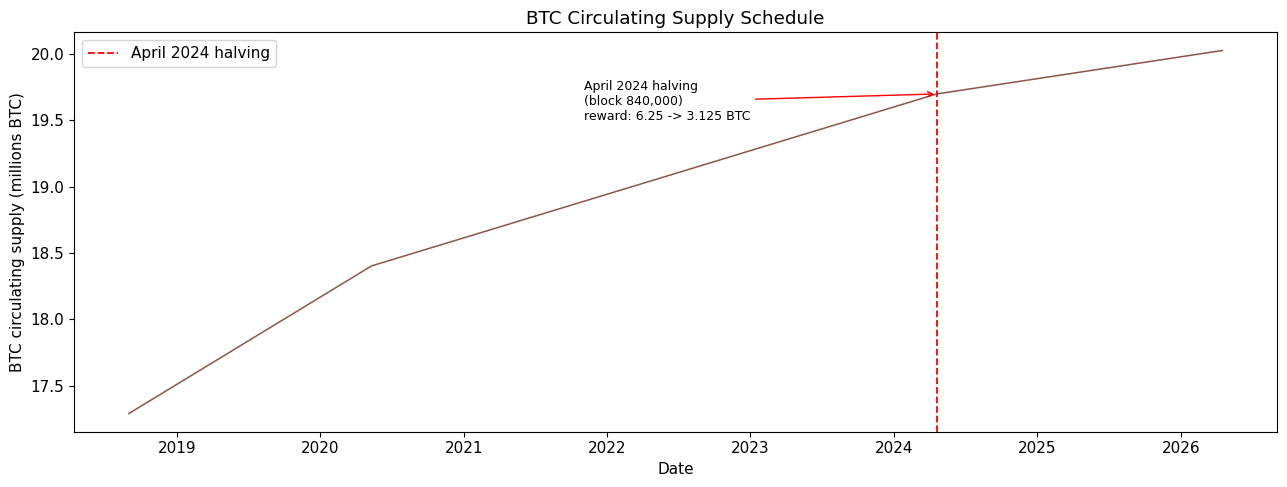

Average daily issuance pre-halving  (2023): 900 BTC/day
Average daily issuance post-halving (2024+): 450 BTC/day


In [8]:
btc_sup_plot = btc_sup.copy()
btc_sup_plot.index = pd.to_datetime(btc_sup_plot.index)

halving_date = pd.Timestamp("2024-04-20")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(btc_sup_plot.index, btc_sup_plot["btc_supply"] / 1e6, color="#8c564b", linewidth=1.1)
ax.axvline(halving_date, color="red", linestyle="--", linewidth=1.3, label="April 2024 halving")
ax.annotate(
    "April 2024 halving\n(block 840,000)\nreward: 6.25 -> 3.125 BTC",
    xy=(halving_date, btc_sup_plot.loc[halving_date:halving_date + pd.Timedelta(days=1), "btc_supply"].iloc[0] / 1e6),
    xytext=(halving_date - pd.Timedelta(days=900), 19.5),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=9
)
ax.set_ylabel("BTC circulating supply (millions BTC)")
ax.set_xlabel("Date")
ax.set_title("BTC Circulating Supply Schedule")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
fig.tight_layout()
plt.show()

# Growth rates
pre  = btc_sup_plot.loc["2023-01-01":"2024-04-01", "btc_supply"].diff().mean()
post = btc_sup_plot.loc["2024-05-01":, "btc_supply"].diff().mean()
print(f"Average daily issuance pre-halving  (2023): {pre:.0f} BTC/day")
print(f"Average daily issuance post-halving (2024+): {post:.0f} BTC/day")


## 5. Pass 2 feature restoration audit

Before Stage P2-3 (feature engineering), three features dropped in Pass 1 were reviewed for
re-introduction. The decision criterion was simple: is the required API credential present in the
`.env` file? If not, the feature is SKIPPED and the Pass 1 drop decision stands.

The table below is parsed from `logs/feature_restoration_decisions.log`.

In [9]:
import re

with open(RESTO_LOG_PATH, "r") as f:
    log_text = f.read()

# Parse sections
sections = re.split(r"===(.+?)===", log_text)
rows = []
for i in range(1, len(sections), 2):
    feature = sections[i].strip()
    body    = sections[i + 1]
    # Skip the STAGE header block
    if "STAGE" in feature:
        continue
    decision_m = re.search(r"Decision:\s*(\w+)", body)
    reason_m   = re.search(r"Reason:\s*(.+?)(?=\n[A-Z]|\Z)", body, re.DOTALL)
    cred_m     = re.search(r"Credential presence:\s*(.+)", body)

    decision = decision_m.group(1) if decision_m else "N/A"
    reason   = reason_m.group(1).strip().replace("\n", " ") if reason_m else "N/A"
    creds    = cred_m.group(1).strip() if cred_m else "N/A"
    rows.append({"Feature": feature, "Decision": decision, "Credentials": creds, "Reason (short)": reason[:120]})

resto_df = pd.DataFrame(rows)

# Style: highlight SKIPPED in red
def color_decision(val):
    if val == "SKIPPED":
        return "background-color: #ffe0e0; color: #990000; font-weight: bold"
    return ""

display(resto_df.style.applymap(color_decision, subset=["Decision"]).set_properties(**{"text-align": "left"}).hide(axis="index"))


Feature,Decision,Credentials,Reason (short)
LOG_MCAP_BUCKET,SKIPPED,"KRX_ID=absent, KRX_PW=absent",KRX_ID and KRX_PW not present in .env. pykrx authenticated mcap endpoint requires both credentials. Feature remains drop
BTC_PERP_LIQUIDATION_COUNT / BTC_PERP_LIQUIDATION_NOTIONAL,SKIPPED,"COINGLASS_API_KEY=absent, LAEVITAS_API_KEY=absent, CCDATA_API_KEY=absent","None of COINGLASS_API_KEY, LAEVITAS_API_KEY, CCDATA_API_KEY present in .env. Liquidation intensity features require a pa"
USDT_PEG_DEVIATION,SKIPPED,No qualifying liquidations provider key found.,"Depends on minute-level BTC/USD source, which piggybacks on liquidations provider. No liquidations provider credentials"


## Summary: what Pass 2 data additions enable downstream

The five files produced in Pass 2 serve two specific pipeline roles:

**Regime gate (BTC/SP500 mcap ratio)**
- `data/derived/btc_supply.parquet` + BTC 1m close --> BTC market cap
- `data/derived/sp500_mcap_proxy.parquet` --> equity market cap denominator
- Together these form the ratio used to switch the model's regime flag. When BTC dominance is
  above the 1-year rolling median, the gate is active and the pipeline may apply different
  signal weights.

**Index-level prediction targets and features**
- `data/yfinance/index/hsi_daily.parquet` and `kospi_daily.parquet` provide the overnight return
  targets (close-to-open) and lagged index features fed into the LightGBM model.
- `data/yfinance/sp500/gspc_daily.parquet` provides the S&P 500 overnight return as a global
  factor feature.

**Feature restoration: all candidates SKIPPED**
- Three Pass 1 drops (log_mcap_bucket, btc_perp_liquidation_count/notional, usdt_peg_deviation)
  were reviewed. All three require API credentials not present in the current `.env`. No new
  features were added in Pass 2. The log at `logs/feature_restoration_decisions.log` serves as
  the audit trail if credentials become available in a future pass.